# Jet Graph Dataset Builder
 Converts raw quark/gluon jet images from HDF5 into a PyTorch Geometric (PyG) graph dataset ready for GNN training.

# What it does
## Stage 1 — Load & Normalize
Reads up to N_EVENTS events from the HDF5 file (X_jets, y, pt, m0). Each jet image is shape (125, 125, 3) — three calorimeter channels. Per-channel min-max normalization is applied across the full loaded dataset.
## Stage 2 — Image → Point Cloud
Each channel's non-zero pixels become 3D points. Node features are 5-dimensional: [x_norm, y_norm, z, intensity, channel_id], where z separates channels in 3D space via LAYER_SEP. Only the top-MAX_NODES pixels by intensity are kept per graph to control size.
## Stage 3 — kNN Graph Construction
A k-nearest-neighbor graph (k=8) is built per event using torch.cdist — no sklearn dependency. The graph is undirected, and edge attributes store Euclidean distances between connected nodes.
## Stage 4 — Save
All Data objects are collated via InMemoryDataset.collate() and saved as a single .pt file containing a (data_obj, slices) tuple.

# Config
ParameterDefaultDescriptionDATA_PATHData/quark-gluon_data-set_n139306.hdf5Input HDF5SAVE_PATHData/jet_pyg_dataset.ptOutput graph datasetN_EVENTS10,000Events to processMAX_NODES1,000Max nodes per graphK_NEIGHBORS8kNN connectivityLAYER_SEP0.5Z-spacing between channelsVISUALIZETrueShow Plotly 3D for first event

# Output — each Data object contains
AttributeShapeDescriptionx(N, 5)Node featurespos(N, 3)3D spatial positionsedge_index(2, E)COO edge connectivityedge_attr(E, 1)Edge distancesy(1,)Label — 0=gluon, 1=quarkpt(1,)Jet transverse momentumm0(1,)Jet invariant mass

# Loading in the next task
pythonimport torch
from torch_geometric.data import InMemoryDataset

# data_obj, slices = torch.load("Data/jet_pyg_dataset.pt")
 Reconstruct individual graphs using slices as needed,
 or wrap in a dataset class for DataLoader use.
The .pt file is a drop-in input for any PyG-based GNN training pipeline (GCN, GAT, ChebNet, EdgeConv, etc.).

# Dependencies
h5py, numpy, torch, torch_geometric, plotly 

In [ ]:
# Install core dependencies
!pip install -q h5py numpy plotly

# Install PyTorch (CPU version for Colab by default)
!pip install -q torch torchvision torchaudio

# Install PyTorch Geometric and its dependencies
!pip install -q torch-geometric
!pip install -q pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \-f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

print("All dependencies installed successfully")

══════════════════════════════════════════════════════════════
#### CONFIG 
══════════════════════════════════════════════════════════════

In [ ]:

DATA_PATH      = r'Data\quark-gluon_data-set_n139306.hdf5'  # ← HDF5 input
SAVE_PATH      = r"Data\jet_pyg_dataset.pt"           # ← output .pt
N_EVENTS       = 10_000   # events to load
MAX_NODES      = 1_000    # top-k pixels per graph
K_NEIGHBORS    = 8        # kNN connectivity
LAYER_SEP      = 0.5      # z-spacing between channels
VISUALIZE      = True     # show Plotly for first event after build
VISUALIZE_IDX  = 0        # which event index to visualise

In [ ]:

import time

import h5py
import numpy as np
import torch
from torch_geometric.data import Data, InMemoryDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[config] device = {DEVICE}")



─────────────────────────────────────────────────────────────
##### 1. DATA LOADING & NORMALISATION
─────────────────────────────────────────────────────────────

In [ ]:
def load_dataset(data_path: str, n_events: int = N_EVENTS):
    """Load up to n_events from HDF5. Returns (X, y, pt, m0)."""
    print(f"[load] reading {data_path} ...")
    with h5py.File(data_path, "r") as f:
        X  = f["X_jets"][:n_events].astype(np.float32)   # (N,125,125,3)
        y  = f["y"]     [:n_events].astype(np.int64)
        pt = f["pt"]    [:n_events].astype(np.float32)
        m0 = f["m0"]    [:n_events].astype(np.float32)
    print(f"[load] {len(X):,} events  X.shape={X.shape}")
    return X, y, pt, m0


def channel_normalize(X: np.ndarray) -> np.ndarray:
    """Per-channel min-max normalisation across the whole dataset."""
    print("[norm] normalising channels ...")
    X_norm = np.empty_like(X)
    for c in range(X.shape[-1]):
        ch = X[..., c]
        lo, hi = ch.min(), ch.max()
        denom = (hi - lo) if hi > lo else 1.0
        X_norm[..., c] = (ch - lo) / denom
        print(f"       ch {c}: min={lo:.4f}  max={hi:.4f}")
    return X_norm



─────────────────────────────────────────────────────────────
##### 2. POINT-CLOUD CONVERSION
─────────────────────────────────────────────────────────────

In [ ]:
def image_to_pointcloud(
    image: np.ndarray,
    max_nodes: int = MAX_NODES,
    layer_sep: float = LAYER_SEP,
):
    """
    Convert a (H, W, C) jet image to a sparse point cloud.

    Node features (5-D): [x_norm, y_norm, z, intensity, channel_id]
    Node positions (3-D): [x_norm, y_norm, z]

    Returns (x_tensor, pos_tensor) or (None, None) for empty events.
    """
    H, W, C = image.shape
    cx, cy  = (W - 1) / 2.0, (H - 1) / 2.0

    all_feats, all_pos = [], []

    for c in range(C):
        channel = image[:, :, c]
        rows, cols = np.nonzero(channel)
        if rows.size == 0:
            continue

        intensities = channel[rows, cols].astype(np.float32)
        x_norm = ((cols - cx) / cx).astype(np.float32)   # in [-1,1]
        y_norm = ((rows - cy) / cy).astype(np.float32)   # in [-1,1]
        z_val  = np.full(rows.size, float(c) * layer_sep, dtype=np.float32)

        feats = np.stack(
            [x_norm, y_norm, z_val, intensities,
             np.full(rows.size, float(c), dtype=np.float32)],
            axis=1,
        )
        all_feats.append(feats)
        all_pos.append(feats[:, :3])

    if not all_feats:
        return None, None

    feats = np.concatenate(all_feats, axis=0)   # (total_pix, 5)
    pos   = np.concatenate(all_pos,   axis=0)   # (total_pix, 3)

    # Keep top-k nodes by intensity
    if len(feats) > max_nodes:
        top_k = np.argpartition(feats[:, 3], -max_nodes)[-max_nodes:]
        feats, pos = feats[top_k], pos[top_k]

    return (
        torch.tensor(feats, dtype=torch.float32),
        torch.tensor(pos,   dtype=torch.float32),
    )

─────────────────────────────────────────────────────────────
##### 3. kNN GRAPH  (pure PyTorch, no sklearn)
─────────────────────────────────────────────────────────────

In [ ]:
def build_knn_graph(
    pos: torch.Tensor,
    k: int = K_NEIGHBORS,
    device: torch.device = DEVICE,
):
    """
    Build an undirected kNN graph via torch.cdist (no self-loops).

    Returns
    -------
    edge_index : (2, E)  COO indices
    edge_attr  : (E, 1)  Euclidean distances
    """
    pos_d = pos.to(device)
    n = pos_d.size(0)
    k = min(k, n - 1)

    dist = torch.cdist(pos_d, pos_d, p=2)                        # (n, n)
    _, idx = dist.topk(k + 1, dim=1, largest=False)              # (n, k+1)
    idx = idx[:, 1:]                                              # drop self

    src = torch.arange(n, device=device).unsqueeze(1).expand(-1, k).reshape(-1)
    dst = idx.reshape(-1)

    # Undirected: add reverse edges then de-duplicate
    edge_index = torch.cat(
        [torch.stack([src, dst]), torch.stack([dst, src])], dim=1
    )
    edge_index = torch.unique(edge_index, dim=1)                  # (2, E)

    d = torch.linalg.norm(
        pos_d[edge_index[0]] - pos_d[edge_index[1]], dim=1, keepdim=True
    )                                                             # (E, 1)

    return edge_index.cpu(), d.cpu()


─────────────────────────────────────────────────────────────
##### 4. PyG DATA OBJECT
─────────────────────────────────────────────────────────────

In [ ]:
def make_pyg_data(
    image: np.ndarray,
    label: int,
    pt_val: float,
    m0_val: float,
    max_nodes: int = MAX_NODES,
    k: int = K_NEIGHBORS,
    device: torch.device = DEVICE,
):
    """Return a PyG Data object for one event, or None if empty."""
    x, pos = image_to_pointcloud(image, max_nodes=max_nodes)
    if x is None:
        return None

    edge_index, edge_attr = build_knn_graph(pos, k=k, device=device)

    return Data(
        x          = x,
        pos        = pos,
        edge_index = edge_index,
        edge_attr  = edge_attr,
        y          = torch.tensor([label],   dtype=torch.long),
        pt         = torch.tensor([pt_val],  dtype=torch.float32),
        m0         = torch.tensor([m0_val],  dtype=torch.float32),
    )


─────────────────────────────────────────────────────────────
##### 5. DATASET BUILD & SAVE
─────────────────────────────────────────────────────────────

In [ ]:
def build_dataset(
    X, y, pt, m0,
    save_path: str = SAVE_PATH,
    max_nodes: int = MAX_NODES,
    k: int = K_NEIGHBORS,
    device: torch.device = DEVICE,
):
    """Convert all events to Data objects, collate, save."""
    data_list, skipped = [], 0
    t0 = time.time()

    for i, (img, label, pt_v, m0_v) in enumerate(zip(X, y, pt, m0)):
        if (i + 1) % 500 == 0:
            rate = (i + 1) / (time.time() - t0)
            print(f"  [{i+1:>6}/{len(X)}]  {rate:.1f} ev/s  skipped={skipped}", end="\r")

        d = make_pyg_data(img, int(label), float(pt_v), float(m0_v),
                          max_nodes=max_nodes, k=k, device=device)
        if d is None:
            skipped += 1
        else:
            data_list.append(d)

    elapsed = time.time() - t0
    print(f"\n[build] {len(data_list):,} graphs  ({skipped} empty skipped)  "
          f"elapsed={elapsed:.1f}s")

    data_obj, slices = InMemoryDataset.collate(data_list)
    torch.save((data_obj, slices), save_path)
    print(f"[save] -> {save_path}")
    return data_list


─────────────────────────────────────────────────────────────
##### 6. 3-D PLOTLY VISUALISATION
─────────────────────────────────────────────────────────────

In [ ]:
def visualize_event(data: Data, event_idx: int = 0):
    """Interactive 3-D Plotly graph: nodes coloured by intensity + edges."""
    pos       = data.pos.numpy()
    intensity = data.x[:, 3].numpy()
    edge_idx  = data.edge_index.numpy()

    # Edge lines (None-separated for Plotly)
    ex, ey, ez = [], [], []
    for s, d_ in edge_idx.T:
        ex += [pos[s, 0], pos[d_, 0], None]
        ey += [pos[s, 1], pos[d_, 1], None]
        ez += [pos[s, 2], pos[d_, 2], None]

    edge_trace = go.Scatter3d(
        x=ex, y=ey, z=ez, mode="lines",
        line=dict(color="rgba(100,160,255,0.12)", width=1),
        hoverinfo="none", name="edges",
    )
    node_trace = go.Scatter3d(
        x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
        mode="markers",
        marker=dict(
            size=3, color=intensity, colorscale="Plasma",
            colorbar=dict(title="Intensity", thickness=12),
            opacity=0.85, line=dict(width=0),
        ),
        text=[f"intensity={v:.3f}  ch={int(data.x[i, 4])}"
              for i, v in enumerate(intensity)],
        hoverinfo="text", name="nodes",
    )

    label_map = {0: "gluon", 1: "quark"}
    label_str = label_map.get(int(data.y.item()), "?")

    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=(f"Jet Graph  |  event {event_idx}  |  {label_str}  |  "
                   f"pt={data.pt.item():.1f}  m0={data.m0.item():.1f}"),
            scene=dict(
                xaxis=dict(title="x (norm)", showgrid=False),
                yaxis=dict(title="y (norm)", showgrid=False),
                zaxis=dict(title="z (channel)", showgrid=False),
                bgcolor="rgb(10,10,20)",
            ),
            paper_bgcolor="rgb(15,15,25)",
            font=dict(color="white"),
            margin=dict(l=0, r=0, t=50, b=0),
        ),
    )
    fig.show()
    print(f"[vis] nodes={data.num_nodes}  edges={data.num_edges}")


─────────────────────────────────────────────────────────────
##### Main
─────────────────────────────────────────────────────────────

In [ ]:
def run():
    X, y, pt, m0 = load_dataset(DATA_PATH, n_events=N_EVENTS)
    X = channel_normalize(X)

    data_list = build_dataset(
        X, y, pt, m0,
        save_path = SAVE_PATH,
        max_nodes = MAX_NODES,
        k         = K_NEIGHBORS,
        device    = DEVICE,
    )

    # Sanity-check on first graph
    g = data_list[0]
    print("\n[sample] first graph:")
    print(f"  x          : {tuple(g.x.shape)}")
    print(f"  pos        : {tuple(g.pos.shape)}")
    print(f"  edge_index : {tuple(g.edge_index.shape)}")
    print(f"  edge_attr  : {tuple(g.edge_attr.shape)}")
    print(f"  y={g.y.item()}  pt={g.pt.item():.2f}  m0={g.m0.item():.2f}")

    if VISUALIZE and data_list:
        idx = min(VISUALIZE_IDX, len(data_list) - 1)
        visualize_event(data_list[idx], event_idx=idx)

    return data_list


# Auto-run whether this is imported (Jupyter) or executed (script)
data_list = run()

[config] device = cuda
[load] reading Data\quark-gluon_data-set_n139306.hdf5 ...
[load] 10,000 events  X.shape=(10000, 125, 125, 3)
[norm] normalising channels ...
       ch 0: min=0.0000  max=10.0881
       ch 1: min=0.0000  max=9.3341
       ch 2: min=0.0000  max=0.3598
  [ 10000/10000]  490.4 ev/s  skipped=0
[build] 10,000 graphs  (0 empty skipped)  elapsed=20.4s
[save] -> Data\jet_pyg_dataset.pt

[sample] first graph:
  x          : (946, 5)
  pos        : (946, 3)
  edge_index : (2, 8932)
  edge_attr  : (8932, 1)
  y=0  pt=107.45  m0=25.23


[vis] nodes=946  edges=8932


# This graph is simulated with help of 3d plotly, if you can't see movable render install the it with pip. For referenve see the screenshot below
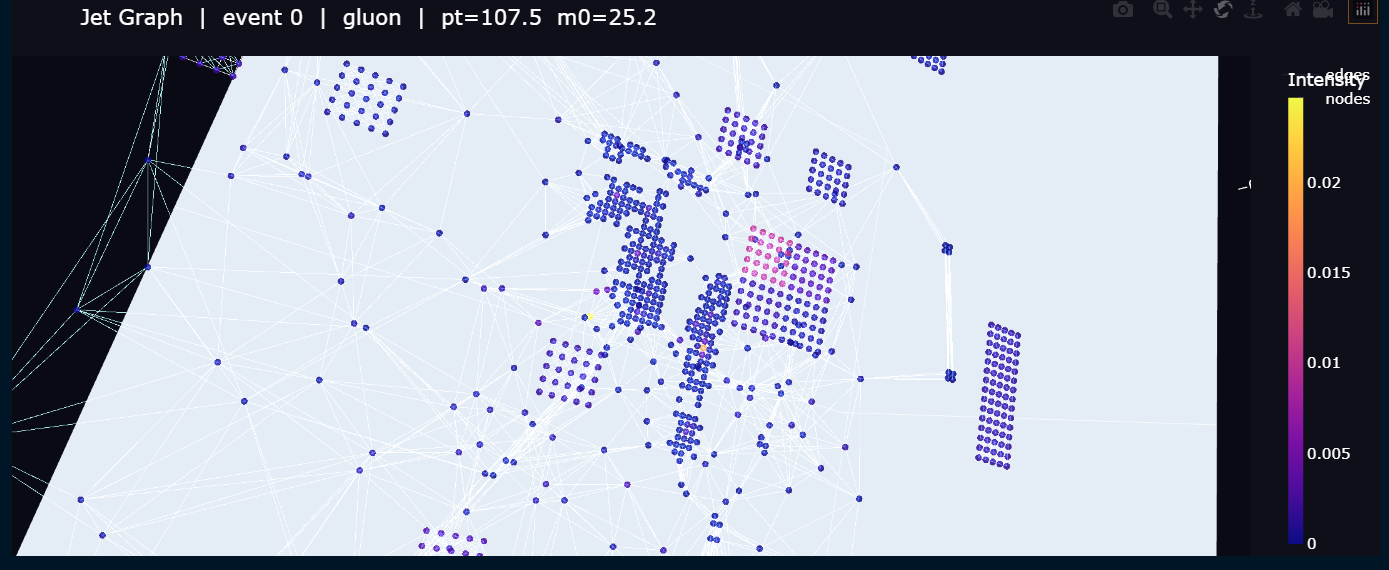


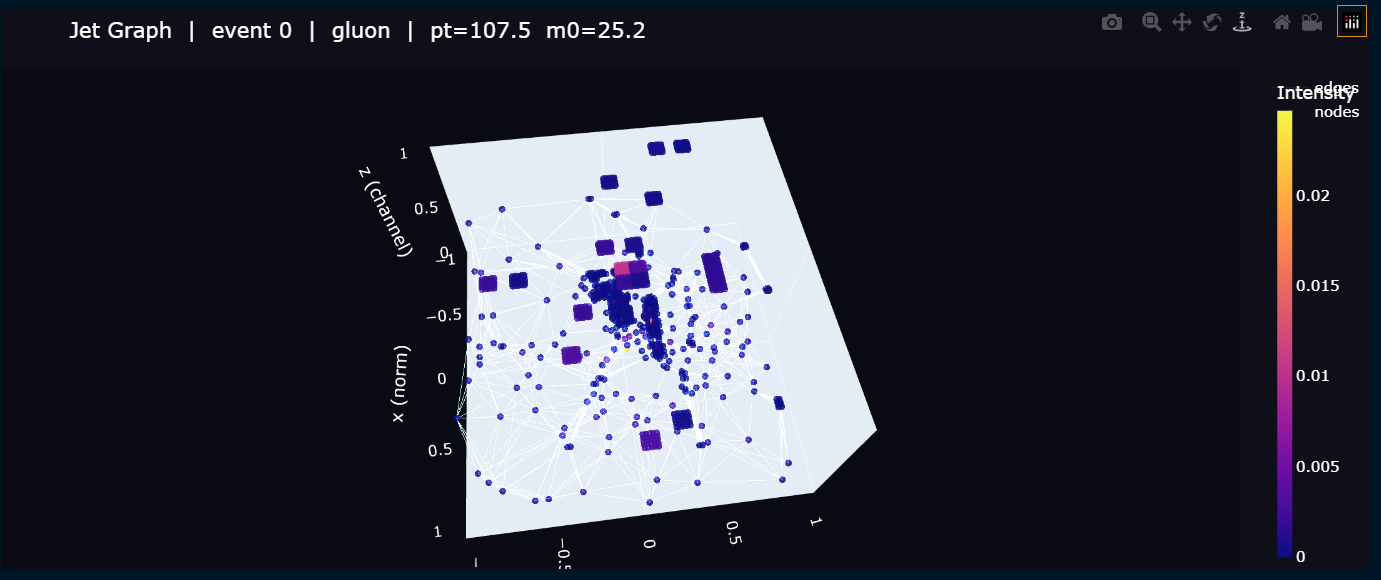


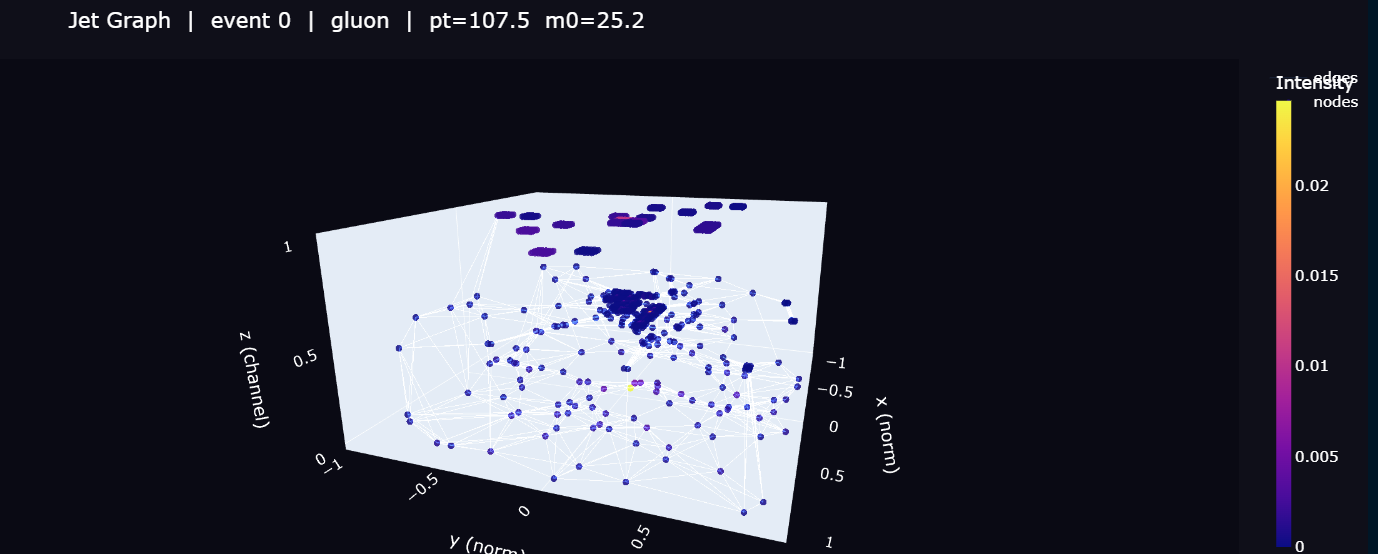